In [1]:
# ============================================
# Step 1: Import Required Libraries
# ============================================

# Library for data manipulation
import pandas as pd

# Library for numerical operations
import numpy as np

# Library for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Model evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Library to save the trained model
import joblib

In [2]:
# ============================================
# Step 2: Load Dataset
# ============================================

df = pd.read_csv("enriched_aqi_dataset.csv")

In [3]:
# ============================================
# Step 3: Display Complete Dataset
# ============================================

df

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,...,AQI_Bucket,Temperature_C,Humidity_%,Wind_Speed_kmh,Year,Month,Day,Hour,Day_of_Week,Season
0,India,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",2026-07-01 23:00:00.000000000,14.465052,78.824187,OZONE,39.0,41.0,...,Good,23.8,68.2,10.6,2026,7,1,23,2,Summer
1,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NO2,13.0,33.0,...,Good,30.6,60.3,19.1,2026,7,1,23,2,Summer
2,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NH3,3.0,5.0,...,Good,28.4,44.3,8.8,2026,7,1,23,2,Summer
3,India,Andhra Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",2026-07-01 23:00:00.000000000,14.438164,79.966814,PM10,45.0,106.0,...,Moderate,39.6,38.9,2.5,2026,7,1,23,2,Summer
4,India,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",2026-07-01 23:00:00.000000000,16.987287,81.736318,PM2.5,5.0,19.0,...,Good,21.4,47.7,28.3,2026,7,1,23,2,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10516,India,Telangana,Milupara,"Sector-2 IMT, Manesar - HSPCB",2026-11-04 23:31:45.905383602,33.348325,80.168752,PM10,32.2,455.0,...,Moderate,31.8,76.0,14.9,2026,11,4,23,2,Autumn
10517,India,Chhattisgarh,Ratlam,"Ambazari, Nagpur - MPCB",2025-07-24 01:12:31.054479927,32.130016,73.777883,NO2,43.8,494.3,...,Very Unhealthy,29.7,70.9,20.1,2025,7,24,1,3,Summer
10518,India,Jammu and Kashmir,Surat,"Sector-1, Noida - UPPCB",2025-01-25 06:18:12.681554465,33.667884,92.966107,OZONE,236.7,492.0,...,Very Unhealthy,35.0,89.4,4.1,2025,1,25,6,5,Winter
10519,India,Telangana,Chennai,"Ram Nagar, Nagpur - MPCB",2027-11-26 01:43:08.116649479,19.089073,93.742956,OZONE,32.8,495.1,...,Moderate,25.5,44.8,20.9,2027,11,26,1,4,Autumn


In [4]:
# ============================================
# Step 4: Display First Five Rows
# ============================================

df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,...,AQI_Bucket,Temperature_C,Humidity_%,Wind_Speed_kmh,Year,Month,Day,Hour,Day_of_Week,Season
0,India,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",2026-07-01 23:00:00.000000000,14.465052,78.824187,OZONE,39.0,41.0,...,Good,23.8,68.2,10.6,2026,7,1,23,2,Summer
1,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NO2,13.0,33.0,...,Good,30.6,60.3,19.1,2026,7,1,23,2,Summer
2,India,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",2026-07-01 23:00:00.000000000,16.186555,81.132190,NH3,3.0,5.0,...,Good,28.4,44.3,8.8,2026,7,1,23,2,Summer
3,India,Andhra Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",2026-07-01 23:00:00.000000000,14.438164,79.966814,PM10,45.0,106.0,...,Moderate,39.6,38.9,2.5,2026,7,1,23,2,Summer
4,India,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",2026-07-01 23:00:00.000000000,16.987287,81.736318,PM2.5,5.0,19.0,...,Good,21.4,47.7,28.3,2026,7,1,23,2,Summer


In [5]:
# ============================================
# Step 5: Display Last Five Rows
# ============================================

df.tail()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,...,AQI_Bucket,Temperature_C,Humidity_%,Wind_Speed_kmh,Year,Month,Day,Hour,Day_of_Week,Season
10516,India,Telangana,Milupara,"Sector-2 IMT, Manesar - HSPCB",2026-11-04 23:31:45.905383602,33.348325,80.168752,PM10,32.2,455.0,...,Moderate,31.8,76.0,14.9,2026,11,4,23,2,Autumn
10517,India,Chhattisgarh,Ratlam,"Ambazari, Nagpur - MPCB",2025-07-24 01:12:31.054479927,32.130016,73.777883,NO2,43.8,494.3,...,Very Unhealthy,29.7,70.9,20.1,2025,7,24,1,3,Summer
10518,India,Jammu and Kashmir,Surat,"Sector-1, Noida - UPPCB",2025-01-25 06:18:12.681554465,33.667884,92.966107,OZONE,236.7,492.0,...,Very Unhealthy,35.0,89.4,4.1,2025,1,25,6,5,Winter
10519,India,Telangana,Chennai,"Ram Nagar, Nagpur - MPCB",2027-11-26 01:43:08.116649479,19.089073,93.742956,OZONE,32.8,495.1,...,Moderate,25.5,44.8,20.9,2027,11,26,1,4,Autumn
10520,India,Assam,Gummidipoondi,"New Colony, Bundi - RSPCB",2025-03-20 19:54:23.351297811,23.094562,72.911819,NH3,10.8,463.6,...,Unhealthy for Sensitive Groups,39.8,37.0,29.1,2025,3,20,19,3,Spring


In [6]:
# ============================================
# Step 6: Dataset Information
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10521 entries, 0 to 10520
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         10521 non-null  object 
 1   state           10521 non-null  object 
 2   city            10521 non-null  object 
 3   station         10521 non-null  object 
 4   last_update     10521 non-null  object 
 5   latitude        10521 non-null  float64
 6   longitude       10521 non-null  float64
 7   pollutant_id    10521 non-null  object 
 8   pollutant_min   10164 non-null  float64
 9   pollutant_max   10164 non-null  float64
 10  pollutant_avg   10164 non-null  float64
 11  AQI             10521 non-null  int64  
 12  AQI_Bucket      10521 non-null  object 
 13  Temperature_C   10521 non-null  float64
 14  Humidity_%      10521 non-null  float64
 15  Wind_Speed_kmh  10521 non-null  float64
 16  Year            10521 non-null  int64  
 17  Month           10521 non-null 

In [7]:
# ============================================
# Step 7: Statistical Summary
# ============================================

df.describe()

,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg,AQI,Temperature_C,Humidity_%,Wind_Speed_kmh,Year,Month,Day,Hour,Day_of_Week
count,10521.000000,10521.000000,10164.000000,10164.000000,10164.000000,10521.000000,10521.000000,10521.000000,10521.000000,10521.000000,10521.000000,10521.000000,10521.000000,10521.000000
mean,21.970147,81.228132,50.536787,233.356966,100.840329,118.237430,27.584621,62.351250,15.071875,2025.986693,6.670374,10.797453,15.327535,2.668092
std,6.798401,6.560283,53.954573,161.227762,81.948059,103.562225,7.231523,18.940531,8.673204,0.669696,2.813108,9.957950,7.882064,1.684897
min,8.514909,70.776774,0.000000,0.000000,0.000000,0.000000,15.000000,30.000000,0.000000,2025.000000,1.000000,1.000000,0.000000,0.000000
25%,16.690571,75.905894,10.000000,62.000000,26.000000,33.000000,21.300000,45.900000,7.600000,2026.000000,5.000000,1.000000,8.000000,2.000000
50%,22.568732,79.946728,29.250000,247.850000,80.600000,89.000000,27.600000,62.200000,15.100000,2026.000000,7.000000,8.000000,18.000000,2.000000
75%,27.759769,86.590325,74.200000,377.225000,170.400000,183.000000,33.900000,79.000000,22.700000,2026.000000,8.000000,19.000000,23.000000,4.000000
max,34.066206,94.636574,262.000000,500.000000,266.000000,499.000000,40.000000,95.000000,30.000000,2027.000000,12.000000,31.000000,23.000000,6.000000


In [8]:
# ============================================
# Step 8: Display Column Names
# ============================================

df.columns

Index(['country', 'state', 'city', 'station', 'last_update', 'latitude',
       'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max',
       'pollutant_avg', 'AQI', 'AQI_Bucket', 'Temperature_C', 'Humidity_%',
       'Wind_Speed_kmh', 'Year', 'Month', 'Day', 'Hour', 'Day_of_Week',
       'Season'],
      dtype='object')

In [9]:
# ============================================
# Step 9: Check Missing Values
# ============================================

df.isnull().sum()

country             0
state               0
city                0
station             0
last_update         0
latitude            0
longitude           0
pollutant_id        0
pollutant_min     357
pollutant_max     357
pollutant_avg     357
AQI                 0
AQI_Bucket          0
Temperature_C       0
Humidity_%          0
Wind_Speed_kmh      0
Year                0
Month               0
Day                 0
Hour                0
Day_of_Week         0
Season              0
dtype: int64

In [10]:
# ============================================
# Step 10: Dataset Shape
# ============================================

df.shape

(10521, 22)

In [11]:
# ============================================
# Step 11: Handle Missing Values
# ============================================

df['pollutant_min'].fillna(df['pollutant_min'].mean(), inplace=True)

df['pollutant_max'].fillna(df['pollutant_max'].mean(), inplace=True)

df['pollutant_avg'].fillna(df['pollutant_avg'].mean(), inplace=True)

In [12]:
# ============================================
# Step 12: Verify Missing Values
# ============================================

df.isnull().sum()

country           0
state             0
city              0
station           0
last_update       0
latitude          0
longitude         0
pollutant_id      0
pollutant_min     0
pollutant_max     0
pollutant_avg     0
AQI               0
AQI_Bucket        0
Temperature_C     0
Humidity_%        0
Wind_Speed_kmh    0
Year              0
Month             0
Day               0
Hour              0
Day_of_Week       0
Season            0
dtype: int64

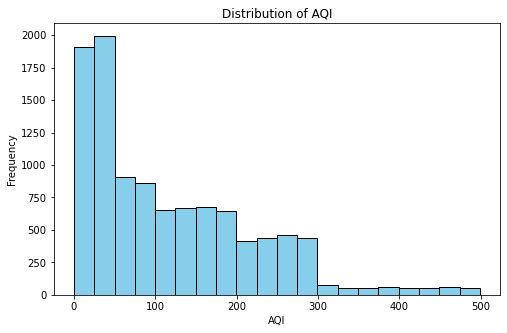

In [13]:
# ============================================
# Step 13: AQI Distribution Histogram
# ============================================

plt.figure(figsize=(8,5))

plt.hist(df['AQI'], bins=20, color='skyblue', edgecolor='black')

plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

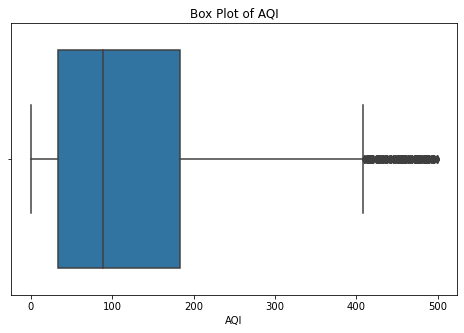

In [14]:
# ============================================
# Step 14: AQI Box Plot
# ============================================

plt.figure(figsize=(8,5))

sns.boxplot(x=df['AQI'])

plt.title("Box Plot of AQI")

plt.show()

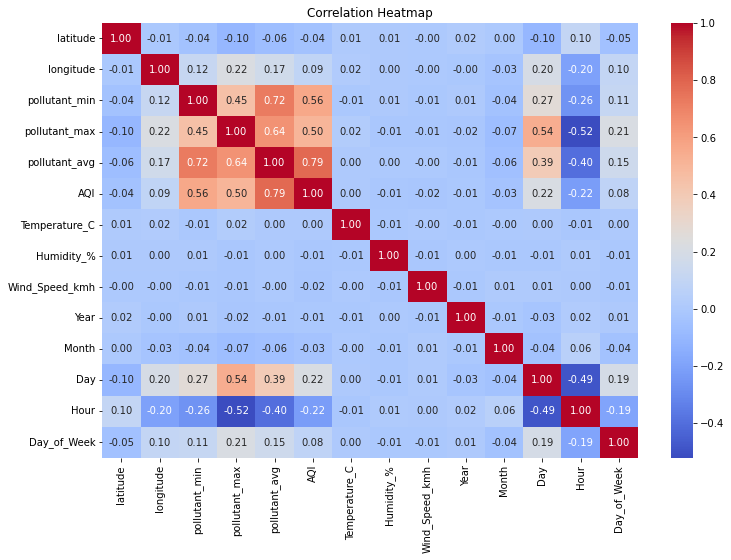

In [15]:
# ============================================
# Step 15: Correlation Heatmap
# ============================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

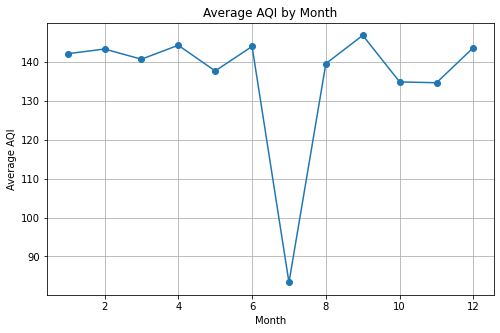

In [16]:
# ============================================
# Step 16: Average AQI by Month
# ============================================

monthly_aqi = df.groupby('Month')['AQI'].mean()

plt.figure(figsize=(8,5))

plt.plot(
    monthly_aqi.index,
    monthly_aqi.values,
    marker='o'
)

plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.grid(True)

plt.show()

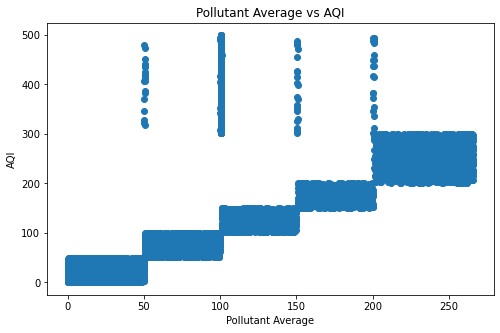

In [17]:
# ============================================
# Step 17: Scatter Plot
# ============================================

plt.figure(figsize=(8,5))

plt.scatter(df['pollutant_avg'], df['AQI'])

plt.title("Pollutant Average vs AQI")
plt.xlabel("Pollutant Average")
plt.ylabel("AQI")

plt.show()

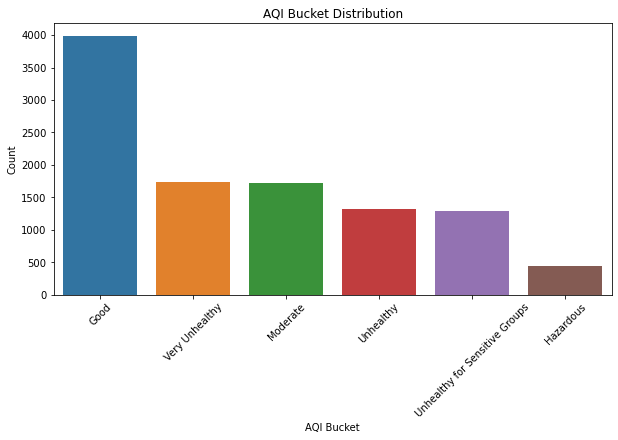

In [18]:
# ============================================
# Step 18: AQI Bucket Distribution
# ============================================

plt.figure(figsize=(10,5))

sns.countplot(
    x='AQI_Bucket',
    data=df,
    order=df['AQI_Bucket'].value_counts().index
)

plt.title("AQI Bucket Distribution")
plt.xlabel("AQI Bucket")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

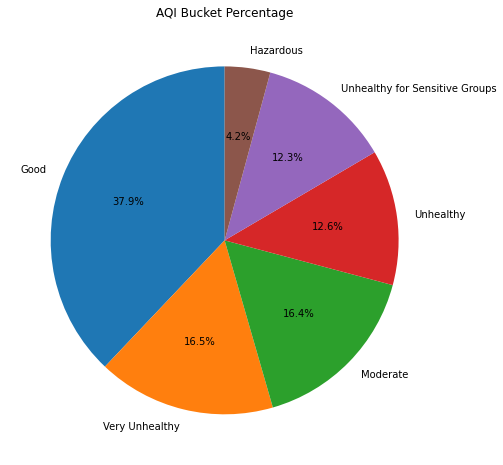

In [19]:
# ============================================
# Step 19: AQI Bucket Percentage
# ============================================

aqi_bucket = df['AQI_Bucket'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    aqi_bucket,
    labels=aqi_bucket.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("AQI Bucket Percentage")

plt.show()

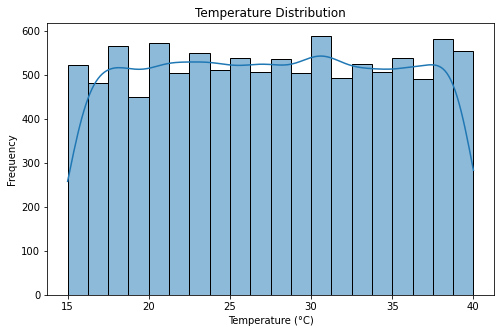

In [20]:
# ============================================
# Step 20: Temperature Distribution
# ============================================

plt.figure(figsize=(8,5))

sns.histplot(df['Temperature_C'], bins=20, kde=True)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

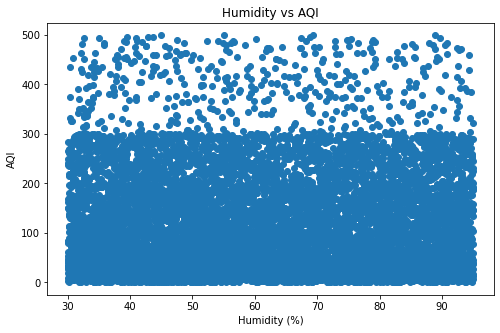

In [21]:
# ============================================
# Step 21: Humidity vs AQI
# ============================================

plt.figure(figsize=(8,5))

plt.scatter(df['Humidity_%'], df['AQI'])

plt.title("Humidity vs AQI")
plt.xlabel("Humidity (%)")
plt.ylabel("AQI")

plt.show()

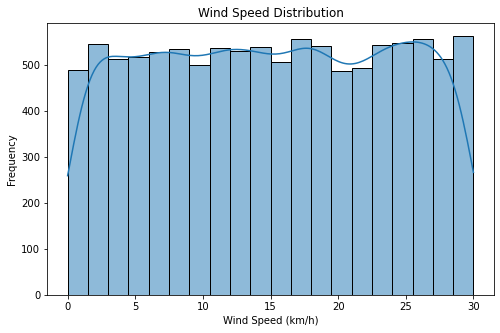

In [22]:
# ============================================
# Step 22: Wind Speed Distribution
# ============================================

plt.figure(figsize=(8,5))

sns.histplot(df['Wind_Speed_kmh'], bins=20, kde=True)

plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Frequency")

plt.show()

In [23]:
# ============================================
# Step 23: Select Features and Target Variable
# ============================================

# Selecting independent variables (features)

X = df[['latitude',
        'longitude',
        'pollutant_min',
        'pollutant_max',
        'pollutant_avg',
        'Temperature_C',
        'Humidity_%',
        'Wind_Speed_kmh',
        'Year',
        'Month',
        'Day',
        'Hour']]

# Selecting dependent variable (target)

y = df['AQI']

In [24]:
# ============================================
# Step 24: Display Features and Target
# ============================================

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

X.head()

Features Shape: (10521, 12)
Target Shape: (10521,)


,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg,Temperature_C,Humidity_%,Wind_Speed_kmh,Year,Month,Day,Hour
0,14.465052,78.824187,39.0,41.0,40.0,23.8,68.2,10.6,2026,7,1,23
1,16.186555,81.132190,13.0,33.0,18.0,30.6,60.3,19.1,2026,7,1,23
2,16.186555,81.132190,3.0,5.0,4.0,28.4,44.3,8.8,2026,7,1,23
3,14.438164,79.966814,45.0,106.0,66.0,39.6,38.9,2.5,2026,7,1,23
4,16.987287,81.736318,5.0,19.0,11.0,21.4,47.7,28.3,2026,7,1,23


In [25]:
# ============================================
# Step 25: Split Dataset into Training and Testing Data
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (8416, 12)
Testing Data Shape: (2105, 12)


In [26]:
# ============================================
# Step 26: Train Linear Regression Model
# ============================================

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [27]:
# ============================================
# Step 27: Predict AQI Values
# ============================================

y_pred = model.predict(X_test)

print("Prediction Completed Successfully!")

Prediction Completed Successfully!


In [28]:
# ============================================
# Step 28: Compare Actual and Predicted AQI
# ============================================

comparison = pd.DataFrame({
    "Actual AQI": y_test,
    "Predicted AQI": y_pred
})

comparison.head(10)

,Actual AQI,Predicted AQI
3819,238,263.068704
8128,64,117.071354
33,47,24.014239
10295,224,259.708903
2138,49,30.935471
7782,290,270.452439
8015,115,132.533209
1393,27,71.904138
8515,152,163.285134
7039,7,-10.119965


In [29]:
# ============================================
# Step 29: Evaluate Model Performance
# ============================================

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)
print("Model Accuracy: {:.2f}%".format(r2*100))

Mean Absolute Error (MAE): 31.509181567451613
Mean Squared Error (MSE): 2959.993731545808
Root Mean Squared Error (RMSE): 54.40582442667152
R² Score: 0.6833397007300765
Model Accuracy: 68.33%


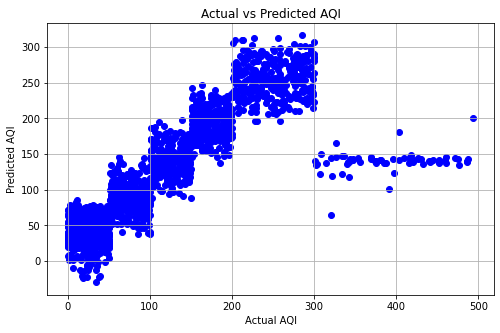

In [30]:
# ============================================
# Step 30: Actual vs Predicted AQI
# ============================================

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred, color='blue')

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")

plt.title("Actual vs Predicted AQI")

plt.grid(True)

plt.show()

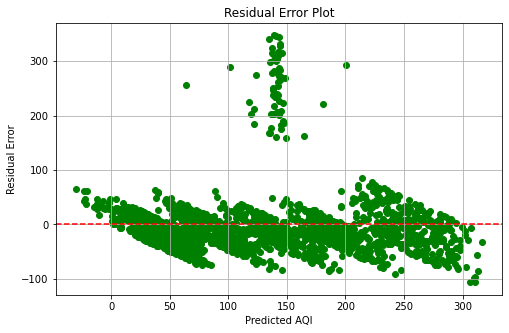

In [31]:
# ============================================
# Step 31: Residual Error Plot
# ============================================

errors = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, errors, color='green')

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted AQI")
plt.ylabel("Residual Error")

plt.title("Residual Error Plot")

plt.grid(True)

plt.show()

In [32]:
# ============================================
# Step 32: Save Trained Model
# ============================================

joblib.dump(model, "air_quality_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [33]:
# ============================================
# Step 33: Project Conclusion
# ============================================

print("""
PROJECT CONCLUSION

1. Successfully loaded the AQI dataset.
2. Performed data preprocessing and handled missing values.
3. Conducted Exploratory Data Analysis (EDA) using multiple visualizations.
4. Selected relevant features for prediction.
5. Split the dataset into training and testing sets.
6. Built a Linear Regression model for AQI prediction.
7. Evaluated the model using MAE, MSE, RMSE, and R² Score.
8. Saved the trained model for future use.

The project demonstrates how Machine Learning can be used to predict Air Quality Index based on environmental factors.
""")


PROJECT CONCLUSION

1. Successfully loaded the AQI dataset.
2. Performed data preprocessing and handled missing values.
3. Conducted Exploratory Data Analysis (EDA) using multiple visualizations.
4. Selected relevant features for prediction.
5. Split the dataset into training and testing sets.
6. Built a Linear Regression model for AQI prediction.
7. Evaluated the model using MAE, MSE, RMSE, and R² Score.
8. Saved the trained model for future use.

The project demonstrates how Machine Learning can be used to predict Air Quality Index based on environmental factors.

